In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix
from scipy.sparse.linalg import aslinearoperator

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, bspline_cy


In [2]:
def QuarterAnullus(deg, N):
    patches = [(2*(bspline.make_knots(deg,0,1,N),),geometry.quarter_annulus())]
    M = topology.PatchMesh(patches)
    M.h_refine();
    M.set_domain_id({1:{0}})
    return M

In [3]:
M = QuarterAnullus(3,5)

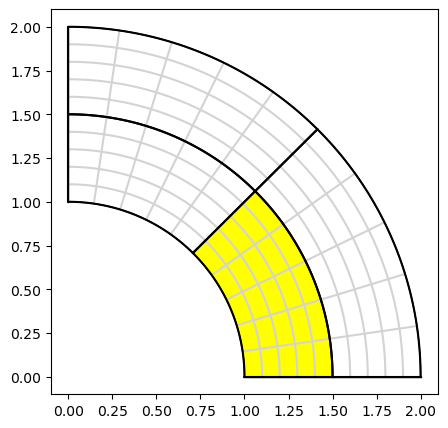

In [8]:
M.plotmesh(knots=1, color={0:'white',1:'yellow'})

In [241]:
kv = bspline.make_knots(1,0,4,4,mult=1)
nodes = np.array([1,1.5,2,3],'d')

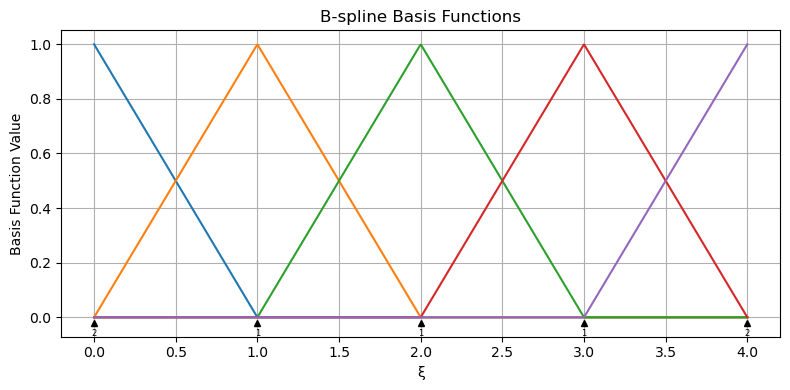

In [242]:
kv.plot(knots=1)

In [243]:
C = bspline.collocation(kv,nodes)

In [244]:
print(len(nodes),kv.numdofs,len(nodes)<=kv.numdofs)

4 5 True


In [247]:
tol=1e-14

for i in range(kv.numdofs):
    a,b = kv.support(i)
    count = sum((a - tol < nodes) & (nodes  < b + tol ))
    print(count,kv.p+1,count<=kv.p+1)

1 2 True
3 2 False
4 2 False
2 2 True
1 2 True


In [248]:
C.shape[0]==np.linalg.matrix_rank(C.toarray())

np.False_

In [163]:
C.toarray()

array([[1. , 0. , 0. , 0. , 0. ],
       [0.5, 0.5, 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. ]])

In [25]:
C.shape[0]-np.linalg.matrix_rank(C.toarray())

2